## Imports ##

In [1]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

## Set seed for reproducibility ##

In [2]:
np.random.seed(42)
torch.manual_seed(42)

## Neural Network ##

In [3]:
# change path to your own path
df = pd.read_csv("/Users/andreasstampedalgaard/Documents/DTU/5. Semester/Explainable AI/XAI_01/data/diabetes-health-indicators-dataset.zip/diabetes_binary_5050split_health_indicators_BRFSS2015.csv")

df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


In [4]:
X = df.drop("Diabetes_binary", axis=1).values
y = df["Diabetes_binary"].values

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.float32
).reshape(-1, 1)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.float32
).reshape(-1, 1)

In [8]:
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True
)

In [9]:
class SimpleNN(nn.Module):
    def __init__(self, input_size, hidden_size=8):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1)
        )

    def forward(self, x):
        return self.network(x)

In [10]:
model = SimpleNN(
    input_size=X_train.shape[1],
    hidden_size=8
)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print(model)

SimpleNN(
  (network): Sequential(
    (0): Linear(in_features=21, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=1, bias=True)
  )
)


In [11]:
epochs = 100
losses = []

for epoch in range(epochs):

    model.train()
    running_loss = 0

    for X_batch, y_batch in train_loader:

        # Forward pass
        logits = model(X_batch)

        # Loss
        loss = criterion(logits, y_batch)

        # Clear previous gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item()

    average_loss = running_loss / len(train_loader)
    losses.append(average_loss)

    if epoch % 10 == 0:
        print(
            f"Epoch {epoch:3d} | "
            f"Loss: {average_loss:.4f}"
        )

Epoch   0 | Loss: 0.6107
Epoch  10 | Loss: 0.5040
Epoch  20 | Loss: 0.5010
Epoch  30 | Loss: 0.5002
Epoch  40 | Loss: 0.4997
Epoch  50 | Loss: 0.4995
Epoch  60 | Loss: 0.4994
Epoch  70 | Loss: 0.4992
Epoch  80 | Loss: 0.4992
Epoch  90 | Loss: 0.4991


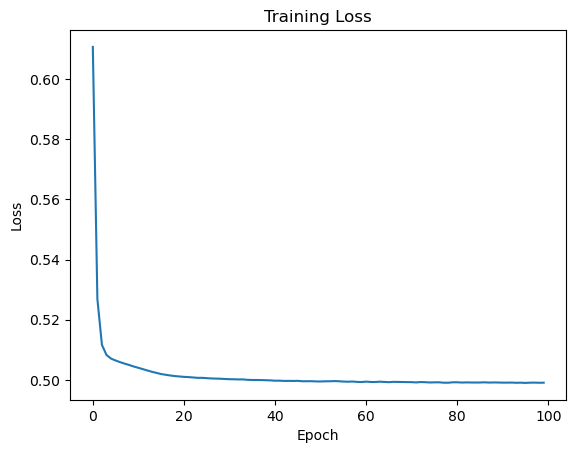

In [12]:
import matplotlib.pyplot as plt

plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

In [ ]:
# accuracy and AUC on the test set
# Accuracy and AUC on the test set
model.eval()

with torch.no_grad():
    logits = model(X_test_tensor)
    probabilities = torch.sigmoid(logits).squeeze(1).numpy()

predictions = (probabilities >= 0.5).astype(int)
y_true = y_test_tensor.squeeze(1).numpy().astype(int)

test_accuracy = accuracy_score(y_true, predictions)
test_auc = roc_auc_score(y_true, probabilities)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test AUC: {test_auc:.4f}")

# Plot accuracy and AUC
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.bar(["Accuracy"], [test_accuracy], color="blue")
plt.ylim(0, 1)
plt.title("Test Accuracy")

plt.subplot(1, 2, 2)
plt.bar(["AUC"], [test_auc], color="green")
plt.ylim(0, 1)
plt.title("Test AUC")

plt.tight_layout()
plt.show()
test_auc = model.evaluate(X_test, y_test, verbose=0)[2]

# plot the accuracy and AUC
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.bar(["Accuracy"], [test_accuracy], color='blue')
plt.ylim(0, 1)
plt.title("Test Accuracy")
plt.subplot(1, 2, 2)
plt.bar(["AUC"], [test_auc], color='green')
plt.ylim(0, 1)
plt.title("Test AUC")
plt.tight_layout()
plt.show()

AttributeError: 'SimpleNN' object has no attribute 'evaluate'

## LIME ##

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder

TARGET = 'Diabetes_binary'
FEATURE_COLS = [c for c in df.columns if c != TARGET]

cat_cols = df[FEATURE_COLS].select_dtypes('category').columns.tolist()
num_cols = df[FEATURE_COLS].select_dtypes('number').columns.tolist()
cat_indices = [FEATURE_COLS.index(c) for c in cat_cols]

print('Categorical:', cat_cols)
print('Numerical  :', num_cols)

Categorical: []
Numerical  : ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


In [42]:
# Drop rows with missing target
mask = df[TARGET].notna()
X_raw = df.loc[mask, FEATURE_COLS].copy()
y_raw = df.loc[mask, TARGET].copy()

# Encode target
le = LabelEncoder()
y = le.fit_transform(y_raw)
class_names = le.classes_.tolist()  # e.g. ['<=50K', '>50K']
print('Classes:', class_names)

# Fill NaN in categoricals with 'Missing' BEFORE astype(str).
# pandas category columns with NaN do not fully convert via astype(str) alone,
# leaving float NaN in the encoded array which makes LIME crash on int().
X_raw[cat_cols] = X_raw[cat_cols].astype(object).fillna('Missing')
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_raw[cat_cols] = oe.fit_transform(X_raw[cat_cols].astype(str))

# Fill NaN in numeric columns with column median
X_raw[num_cols] = X_raw[num_cols].fillna(X_raw[num_cols].median())

X = X_raw.values.astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Classes: [0.0, 1.0]
Train: (56553, 21), Test: (14139, 21)


In [43]:
import lime
import lime.lime_tabular

# Build the categorical_names dict required by LIME
categorical_names = {}
for i, col in enumerate(cat_cols):
    col_idx = FEATURE_COLS.index(col)
    categorical_names[col_idx] = oe.categories_[i]

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train,
    feature_names=FEATURE_COLS,
    class_names=class_names,
    categorical_features=cat_indices,
    categorical_names=categorical_names,
    mode='classification',
    random_state=42,
)
print('Explainer ready.')

Explainer ready.


In [45]:
# Pick the first test instance predicted as 1.0
model.eval()

with torch.no_grad():
    X_test_scaled = scaler.transform(X_test)
    test_tensor = torch.as_tensor(X_test_scaled, dtype=torch.float32)
    positive_probs = torch.sigmoid(model(test_tensor)).squeeze(1).numpy()

predictions = (positive_probs >= 0.5).astype(int)

# Select the first test instance predicted as class 1
target_class = le.transform([1.0])[0]
matching_indices = np.where(predictions == target_class)[0]
if len(matching_indices) == 0:
    raise ValueError("No test instances were predicted as class 1.")

idx = matching_indices[0]
instance = X_test[idx]
pred_class = class_names[predictions[idx]]
pred_proba = np.array([1 - positive_probs[idx], positive_probs[idx]])

print(f"Explaining instance index {idx}")
print(f"Predicted class: {pred_class}")
print(f"Class probabilities: {dict(zip(class_names, pred_proba.round(3)))}")

Explaining instance index 0
Predicted class: 1.0
Class probabilities: {0.0: 0.08, 1.0: 0.92}


/Users/andreasstampedalgaard/miniforge3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


/Users/andreasstampedalgaard/miniforge3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


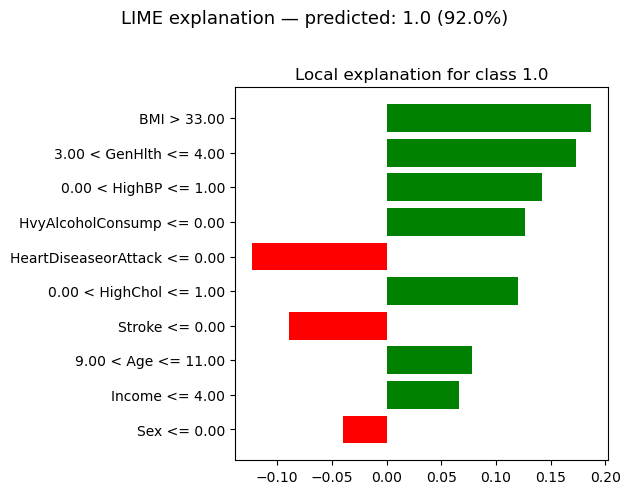

In [48]:
def predict_proba_fn(x):
    x = np.asarray(x, dtype=np.float32)
    x_scaled = scaler.transform(x)  # apply the same scaling used during training
    model.eval()
    with torch.no_grad():
        logits = model(torch.as_tensor(x_scaled, dtype=torch.float32))
        probs = torch.sigmoid(logits).squeeze(-1).numpy()
    return np.column_stack([1.0 - probs, probs])

exp = explainer.explain_instance(
    data_row=instance,
    predict_fn=predict_proba_fn,
    num_features=10,
    num_samples=5000,
)

# Inline plot inside the notebook
fig = exp.as_pyplot_figure(label=le.transform(['1.0'])[0])
fig.suptitle(f'LIME explanation — predicted: {pred_class} ({pred_proba.max():.1%})',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [50]:
# Also inspect the raw weights as a DataFrame
weights = exp.as_list(label=le.transform(['1.0'])[0])
pd.DataFrame(weights, columns=['feature condition', 'LIME weight']).sort_values(
    'LIME weight', key=abs, ascending=False
)

,feature condition,LIME weight
0,BMI > 33.00,0.186997
1,3.00 < GenHlth <= 4.00,0.173391
2,0.00 < HighBP <= 1.00,0.141703
3,HvyAlcoholConsump <= 0.00,0.126412
4,HeartDiseaseorAttack <= 0.00,-0.123010
5,0.00 < HighChol <= 1.00,0.119821
6,Stroke <= 0.00,-0.089417
7,9.00 < Age <= 11.00,0.077694
8,Income <= 4.00,0.065904
9,Sex <= 0.00,-0.039589


/Users/andreasstampedalgaard/miniforge3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/andreasstampedalgaard/miniforge3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/andreasstampedalgaard/miniforge3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


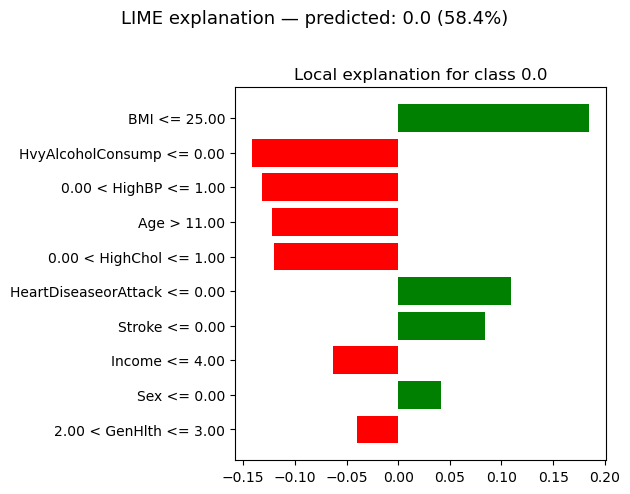

In [55]:
probabilities2 = predict_proba_fn(X_test)
predictions2 = np.argmax(probabilities2, axis=1)

target_class2 = le.transform([0.0])[0]
low_income_mask = predictions2 == target_class2

if not np.any(low_income_mask):
    raise ValueError("No test instances were predicted as class 0.")

idx2 = np.where(low_income_mask)[0][0]

instance2 = X_test[idx2]
pred_class2 = class_names[predictions2[idx2]]
pred_proba2 = probabilities2[idx2]

exp2 = explainer.explain_instance(
    data_row=instance2,
    predict_fn=predict_proba_fn,
    num_features=10,
    num_samples=5000,
)

# LIME defaults to class 1 unless we specify the label explicitly
exp2 = explainer.explain_instance(
    data_row=instance2,
    predict_fn=predict_proba_fn,
    labels=(target_class2,),
    num_features=10,
    num_samples=5000,
)

fig2 = exp2.as_pyplot_figure(label=target_class2)
fig2.suptitle(
    f"LIME explanation — predicted: {pred_class2} "
    f"({pred_proba2.max():.1%})",
    fontsize=13,
    y=1.02,
)
plt.tight_layout()
plt.show()

In [58]:
from collections import Counter

N_RUNS = 10
top_k = 5
pos_label = le.transform(['1.0'])[0]

feature_counts = Counter()
for seed in range(N_RUNS):
    rng = np.random.default_rng(seed)
    idx = rng.integers(len(X_test))
    instance = X_test[idx]

    local_exp = explainer.explain_instance(
        data_row=instance,
        predict_fn=predict_proba_fn,
        labels=(pos_label,),
        num_features=top_k,
        num_samples=5000,
    )

    for feat_cond, _ in local_exp.as_list(label=pos_label):
        feat_name = next((f for f in FEATURE_COLS if feat_cond.startswith(f)), feat_cond)
        feature_counts[feat_name] += 1
    for feat_name, _ in local_exp.as_list(label=pos_label):
        feature_counts[feat_name] += 1

stability_df = pd.DataFrame(
    feature_counts.most_common(), columns=['feature condition', f'appearances (/{N_RUNS})']
)
print(stability_df.to_string(index=False))

/Users/andreasstampedalgaard/miniforge3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/andreasstampedalgaard/miniforge3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/andreasstampedalgaard/miniforge3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/andreasstampedalgaard/miniforge3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/andreasstampedalgaard/miniforge3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does n

           feature condition  appearances (/10)
     0.00 < HighChol <= 1.00                 14
       0.00 < HighBP <= 1.00                 10
                     GenHlth                  8
        HeartDiseaseorAttack                  8
HeartDiseaseorAttack <= 0.00                  7
             GenHlth <= 2.00                  6
         9.00 < Age <= 11.00                  6
                      HighBP                  5
              HighBP <= 0.00                  5
           HvyAlcoholConsump                  3
   HvyAlcoholConsump <= 0.00                  3
                         Age                  3
                    HighChol                  3
            HighChol <= 0.00                  3
              GenHlth > 4.00                  2
       6.00 < Income <= 8.00                  2
      3.00 < GenHlth <= 4.00                  2
                         BMI                  2
                BMI <= 25.00                  2
                 Age <= 7.00            

In [60]:
N_EXPLAIN = 100  # increase for smoother averages (slower)
rng = np.random.default_rng(0)
sample_idx = rng.choice(len(X_test), size=N_EXPLAIN, replace=False)

weight_accumulator = {f: [] for f in FEATURE_COLS}

for i in sample_idx:
    e = explainer.explain_instance(
        data_row=X_test[i],
        predict_fn=predict_proba_fn,
        labels=(pos_label,),
        num_features=len(FEATURE_COLS),
        num_samples=1000,
    )
    for feat_cond, w in e.as_list(label=pos_label):
        # feat_cond looks like "age > 40.00" — strip to bare feature name
        feat = next((f for f in FEATURE_COLS if feat_cond.startswith(f)), None)
        if feat:
            weight_accumulator[feat].append(w)

mean_abs_weight = {
    f: np.mean(np.abs(ws)) for f, ws in weight_accumulator.items() if ws
}
global_df = pd.DataFrame(
    sorted(mean_abs_weight.items(), key=lambda x: x[1], reverse=True),
    columns=['feature', 'mean |LIME weight|']
)
print(global_df.to_string(index=False))

/Users/andreasstampedalgaard/miniforge3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/andreasstampedalgaard/miniforge3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/andreasstampedalgaard/miniforge3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/andreasstampedalgaard/miniforge3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/andreasstampedalgaard/miniforge3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does n

             feature  mean |LIME weight|
             GenHlth            0.236626
                 BMI            0.186987
                 Age            0.146634
              HighBP            0.136656
   HvyAlcoholConsump            0.129122
            HighChol            0.117057
HeartDiseaseorAttack            0.109660
              Stroke            0.087251
              Income            0.065804
                 Sex            0.036678
            DiffWalk            0.025029
            MentHlth            0.017367
         NoDocbcCost            0.015103
           Education            0.013499
              Fruits            0.011278
        PhysActivity            0.010219
            PhysHlth            0.009440
              Smoker            0.008720
           CholCheck            0.000000
             Veggies            0.000000
       AnyHealthcare            0.000000


/Users/andreasstampedalgaard/miniforge3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/andreasstampedalgaard/miniforge3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/andreasstampedalgaard/miniforge3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/andreasstampedalgaard/miniforge3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


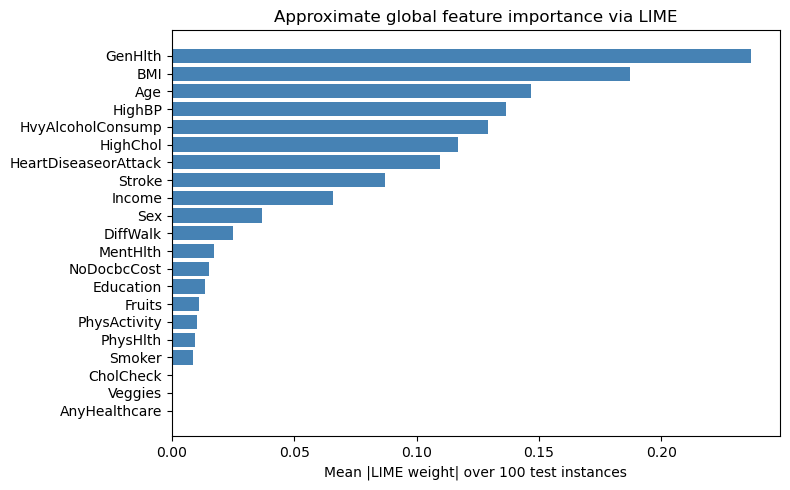

In [61]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(global_df['feature'][::-1], global_df['mean |LIME weight|'][::-1], color='steelblue')
ax.set_xlabel('Mean |LIME weight| over 100 test instances')
ax.set_title('Approximate global feature importance via LIME')
plt.tight_layout()
plt.show()

## SHAP ##

In [63]:
import shap

pos_label_idx = le.transform(['1.0'])[0]

model.eval()

# DeepExplainer supports PyTorch neural networks.
background = X_train_tensor[:100]

_deep_explainer = shap.DeepExplainer(model, background)

class BinaryDeepExplainer:
    def __init__(self, explainer):
        self.explainer = explainer

        base = explainer.expected_value
        if isinstance(base, torch.Tensor):
            base = base.detach().cpu().numpy()

        base = float(np.asarray(base).reshape(-1)[0])
        self.expected_value = np.array([-base, base])

    def shap_values(self, X):
        X_tensor = torch.as_tensor(X, dtype=torch.float32)
        values = self.explainer.shap_values(X_tensor)

        if isinstance(values, list):
            values = values[0]

        if isinstance(values, torch.Tensor):
            values = values.detach().cpu().numpy()

        values = np.asarray(values)

        # Remove the singleton output dimension, if present.
        if values.ndim == 3:
            values = values[..., 0]

        # Represent binary classes as negative and positive logits.
        return [-values, values]

shap_tree_explainer = BinaryDeepExplainer(_deep_explainer)

# The neural network was trained on standardized features.
X_test = X_test_scaled

# Compute exact SHAP values for a 500-instance sample of the test set.
# Returns a list [class_0_array, class_1_array] or a 3-D array depending on shap version.
N_SHAP = 500
shap_vals_raw = shap_tree_explainer.shap_values(X_test[:N_SHAP])

if isinstance(shap_vals_raw, list):
    sv_pos_all = shap_vals_raw[pos_label_idx]           # (N_SHAP, n_features)
else:
    sv_pos_all = shap_vals_raw[:, :, pos_label_idx]     # (N_SHAP, n_features)

ev = shap_tree_explainer.expected_value
expected_val = ev[pos_label_idx] if hasattr(ev, '__len__') else float(ev)

print(f'SHAP values shape : {sv_pos_all.shape}')
print(f'Baseline (E[f(X)]): {expected_val:.4f}')

SHAP values shape : (500, 21)
Baseline (E[f(X)]): 0.0888


Instance predicted as: 1.0 (92.0%)


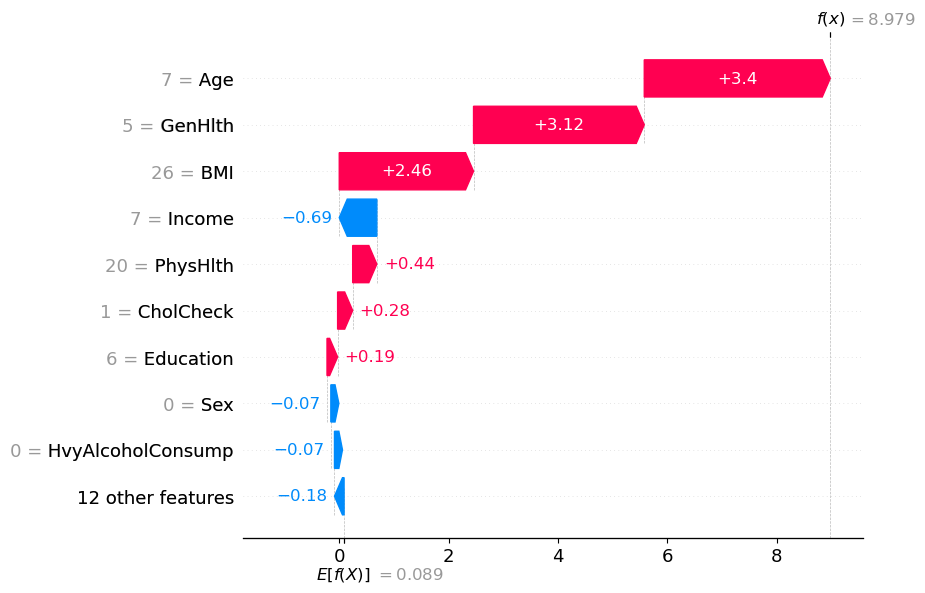

In [64]:
sv_hi = shap_tree_explainer.shap_values(instance.reshape(1, -1))
sv_hi_pos = (sv_hi[pos_label_idx][0] if isinstance(sv_hi, list) else sv_hi[0, :, pos_label_idx])

shap_exp_hi = shap.Explanation(
    values=sv_hi_pos,
    base_values=expected_val,
    data=instance,
    feature_names=FEATURE_COLS,
)
print(f'Instance predicted as: {pred_class} ({pred_proba.max():.1%})')
shap.plots.waterfall(shap_exp_hi)

Instance predicted as: 0.0 (58.4%)


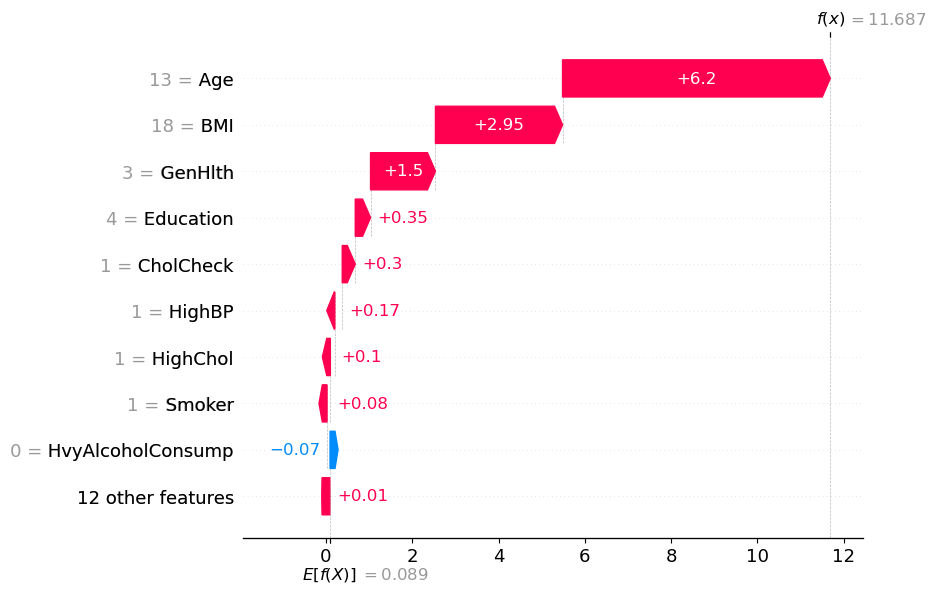

In [65]:
sv_lo = shap_tree_explainer.shap_values(instance2.reshape(1, -1))
sv_lo_pos = (sv_lo[pos_label_idx][0] if isinstance(sv_lo, list) else sv_lo[0, :, pos_label_idx])

shap_exp_lo = shap.Explanation(
    values=sv_lo_pos,
    base_values=expected_val,
    data=instance2,
    feature_names=FEATURE_COLS,
)
print(f'Instance predicted as: {pred_class2} ({pred_proba2.max():.1%})')
shap.plots.waterfall(shap_exp_lo)

/var/folders/sl/435gx6y958q0v8qp_2lgbcww0000gn/T/ipykernel_55926/3551569990.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv_pos_all, X_test[:N_SHAP], feature_names=FEATURE_COLS)


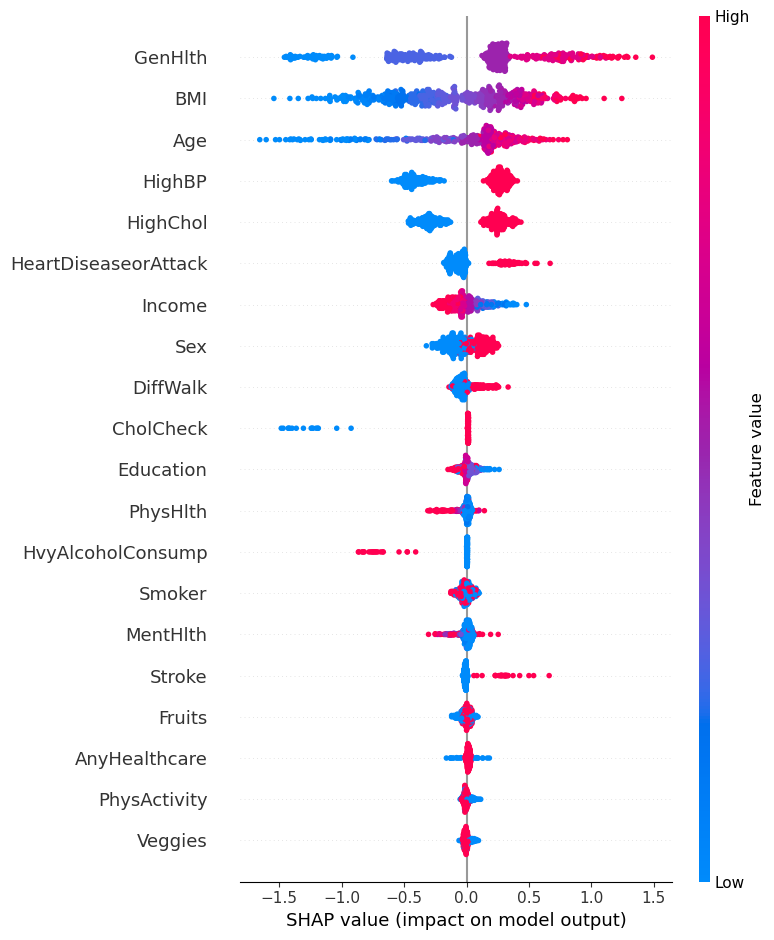

In [66]:
shap.summary_plot(sv_pos_all, X_test[:N_SHAP], feature_names=FEATURE_COLS)

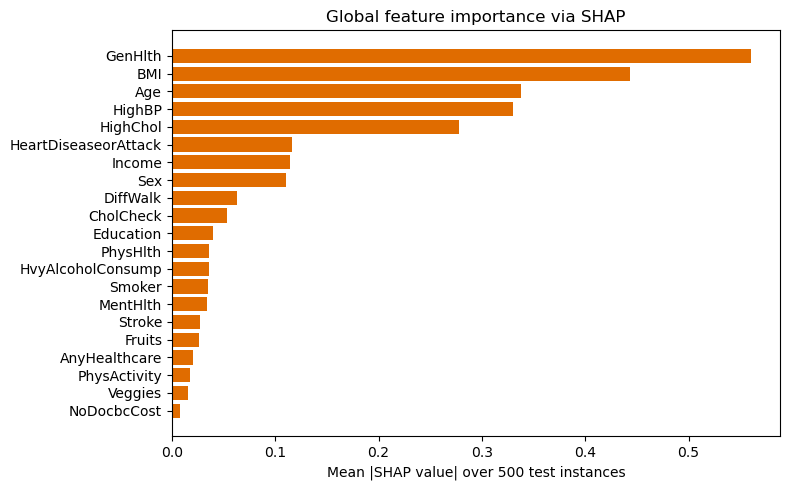

             feature  mean |SHAP|
             GenHlth     0.560425
                 BMI     0.443464
                 Age     0.337901
              HighBP     0.329680
            HighChol     0.278172
HeartDiseaseorAttack     0.116630
              Income     0.114486
                 Sex     0.110108
            DiffWalk     0.063022
           CholCheck     0.053348
           Education     0.040251
            PhysHlth     0.036078
   HvyAlcoholConsump     0.035588
              Smoker     0.035178
            MentHlth     0.033602
              Stroke     0.027526
              Fruits     0.026506
       AnyHealthcare     0.020031
        PhysActivity     0.017495
             Veggies     0.015736
         NoDocbcCost     0.007865


In [67]:
mean_abs_shap = np.mean(np.abs(sv_pos_all), axis=0)
shap_global_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'mean |SHAP|': mean_abs_shap,
}).sort_values('mean |SHAP|', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(shap_global_df['feature'][::-1], shap_global_df['mean |SHAP|'][::-1], color='#e06c00')
ax.set_xlabel('Mean |SHAP value| over 500 test instances')
ax.set_title('Global feature importance via SHAP')
plt.tight_layout()
plt.show()
print(shap_global_df.to_string(index=False))

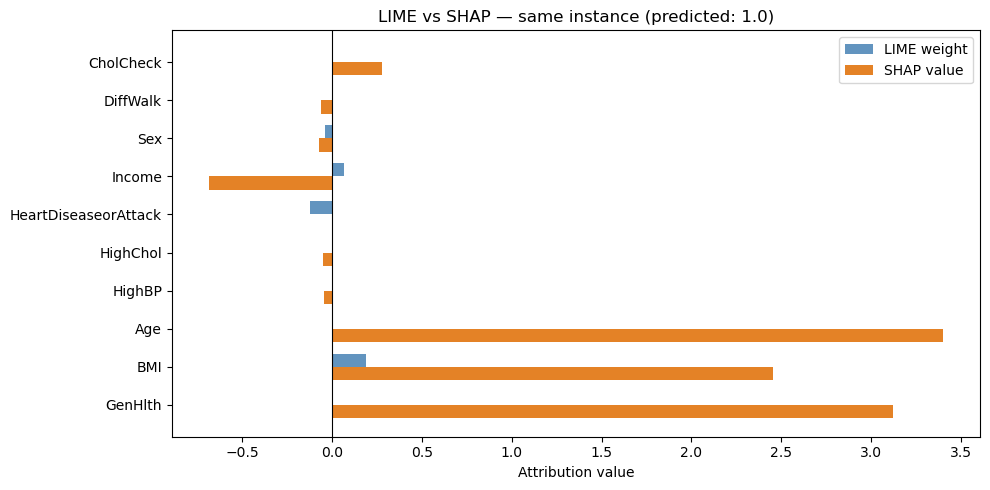

In [68]:
lime_by_feature = {}
for feat_cond, w in exp.as_list(label=pos_label):
    feat = next((f for f in FEATURE_COLS if feat_cond.startswith(f)), None)
    if feat:
        lime_by_feature[feat] = w

# SHAP values for the same instance
shap_by_feature = dict(zip(FEATURE_COLS, sv_hi_pos))

# Compare over the top-10 features by mean |SHAP| (global ranking)
top10 = shap_global_df['feature'].head(10).tolist()
lime_local  = [lime_by_feature.get(f, 0) for f in top10]
shap_local  = [shap_by_feature[f] for f in top10]

x = np.arange(len(top10))
bar_w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(x + bar_w/2, lime_local,  bar_w, label='LIME weight', color='steelblue', alpha=0.85)
ax.barh(x - bar_w/2, shap_local,  bar_w, label='SHAP value',  color='#e06c00',  alpha=0.85)
ax.set_yticks(x)
ax.set_yticklabels(top10)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Attribution value')
ax.set_title(f'LIME vs SHAP — same instance (predicted: {pred_class})')
ax.legend()
plt.tight_layout()
plt.show()

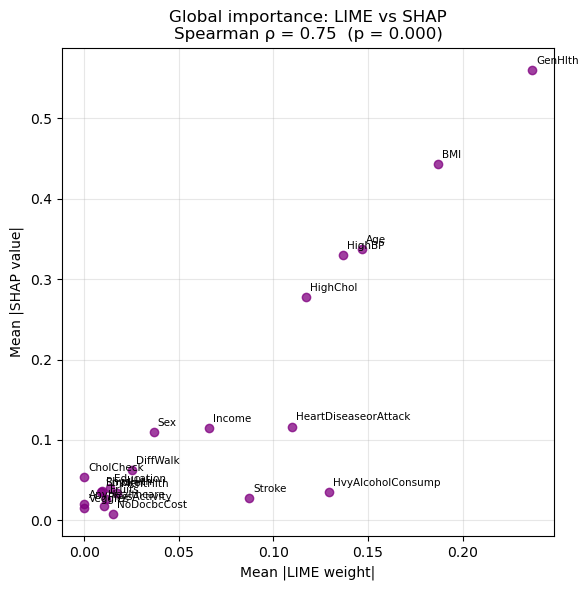

Spearman rank correlation: ρ = 0.752,  p = 0.0001


In [69]:
from scipy.stats import spearmanr

# Align global rankings by feature name
lime_series = global_df.set_index('feature')['mean |LIME weight|']
shap_series = shap_global_df.set_index('feature')['mean |SHAP|']
aligned = pd.DataFrame({'LIME': lime_series, 'SHAP': shap_series}).dropna()

rho, pval = spearmanr(aligned['LIME'], aligned['SHAP'])

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(aligned['LIME'], aligned['SHAP'], color='purple', alpha=0.75, zorder=3)
for feat, row in aligned.iterrows():
    ax.annotate(feat, (row['LIME'], row['SHAP']), fontsize=7.5, ha='left', va='bottom',
                xytext=(3, 3), textcoords='offset points')
ax.set_xlabel('Mean |LIME weight|')
ax.set_ylabel('Mean |SHAP value|')
ax.set_title(f'Global importance: LIME vs SHAP\nSpearman ρ = {rho:.2f}  (p = {pval:.3f})')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f'Spearman rank correlation: ρ = {rho:.3f},  p = {pval:.4f}')